# Delhi Daily Climate — Temperature Prediction

Predicts daily mean temperature (`meantemp`) in Delhi using calendar-based seasonality features and same-day weather readings (humidity, wind speed, pressure).

- **Train:** `DailyDelhiClimateTrain.csv` — 2013-01-01 to 2017-01-01 (1,462 days)
- **Test:** `DailyDelhiClimateTest.csv` — 2017-01-01 to 2017-04-24 (114 days), used purely for validation

Source data: [Daily Delhi Climate Data on Kaggle](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## 1. Load data

In [2]:
train = pd.read_csv("DailyDelhiClimateTrain.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
test = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train)} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test)} rows)")
train.head()

Train: 2013-01-01 to 2017-01-01  (1462 rows)
Test:  2017-01-01 to 2017-04-24  (114 rows)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## 2. Data quality check

`meanpressure` contains clearly invalid readings (raw range runs from about -3 hPa to 7,679 hPa;
realistic sea-level pressure is roughly 950-1050 hPa). Rather than drop rows and break the time series, we clip the column to a realistic range.

In [3]:
print(train['meanpressure'].describe())

for df in (train, test):
    df["meanpressure"] = df["meanpressure"].clip(950, 1050)

count    1462.000000
mean     1011.104548
std       180.231668
min        -3.041667
25%      1001.580357
50%      1008.563492
75%      1014.944901
max      7679.333333
Name: meanpressure, dtype: float64


## 3. Feature engineering

- Cyclical (sin/cos) encoding of day-of-year and month so the model sees Dec 31 → Jan 1 as adjacent, not a hard jump
- Year, to capture any warming/cooling trend across years
- Same-day humidity, wind speed, and (cleaned) pressure as exogenous predictors
- Lagged `meantemp` (1, 3, 7 days back) and a 7-day rolling mean, to capture short-term momentum. Train and test are concatenated (they're chronologically contiguous) before these are computed so the first days of test correctly pick up the last few days of train, then split back apart. Each lag/rolling value only looks backward, so no test-period target leaks into a feature.


In [4]:
LAGS = (1, 3, 7)
ROLLING_WINDOW = 7

def add_features(df):
    df = df.copy()
    doy = df["date"].dt.dayofyear
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    df["month"] = df["date"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["year"] = df["date"].dt.year
    return df

combined = pd.concat([train.assign(split="train"), test.assign(split="test")],
                      ignore_index=True).sort_values("date").reset_index(drop=True)
combined = add_features(combined)

for lag in LAGS:
    combined[f"meantemp_lag{lag}"] = combined["meantemp"].shift(lag)
combined[f"meantemp_roll{ROLLING_WINDOW}"] = (
    combined["meantemp"].shift(1).rolling(ROLLING_WINDOW).mean()
)

LAG_FEATURES = [f"meantemp_lag{lag}" for lag in LAGS] + [f"meantemp_roll{ROLLING_WINDOW}"]
combined = combined.dropna(subset=LAG_FEATURES).reset_index(drop=True)

train_fe = combined[combined["split"] == "train"].reset_index(drop=True)
test_fe = combined[combined["split"] == "test"].reset_index(drop=True)

FEATURES = ["doy_sin", "doy_cos", "month_sin", "month_cos", "year",
            "humidity", "wind_speed", "meanpressure"] + LAG_FEATURES
TARGET = "meantemp"

X_train, y_train = train_fe[FEATURES], train_fe[TARGET]
X_test, y_test = test_fe[FEATURES], test_fe[TARGET]

## 4. Train and compare models

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df.round(3)

,MAE,RMSE,R2
Linear Regression,1.303,1.592,0.937
Random Forest,1.286,1.628,0.934
Gradient Boosting,1.387,1.750,0.924


In [6]:
best_name = results_df.index[0]
best_preds = predictions[best_name]
print(f"Best model: {best_name}")

Best model: Linear Regression


## 5. Validation: predicted vs actual on test set

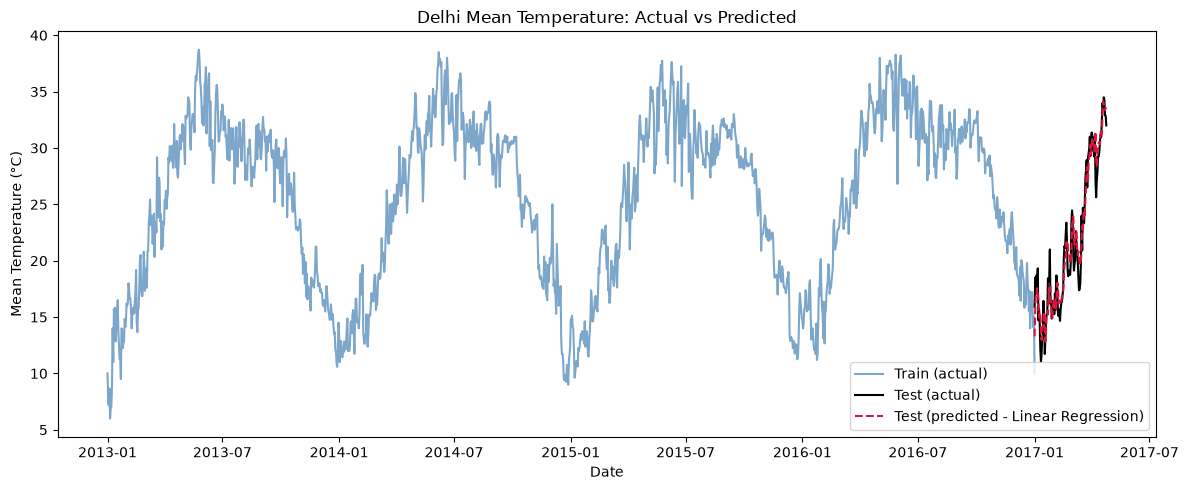

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(train["date"], train["meantemp"], label="Train (actual)", color="steelblue", alpha=0.7)
plt.plot(test["date"], test["meantemp"], label="Test (actual)", color="black")
plt.plot(test["date"], best_preds, label=f"Test (predicted - {best_name})", color="crimson", linestyle="--")
plt.title("Delhi Mean Temperature: Actual vs Predicted")
plt.xlabel("Date"); plt.ylabel("Mean Temperature (°C)"); plt.legend(); plt.tight_layout()
plt.show()

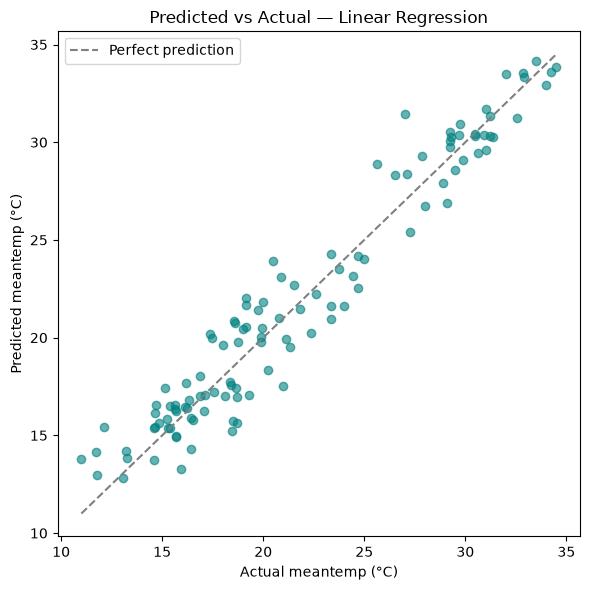

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.6, color="teal")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="gray", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual meantemp (°C)"); plt.ylabel("Predicted meantemp (°C)")
plt.title(f"Predicted vs Actual — {best_name}"); plt.legend(); plt.tight_layout()
plt.show()

## 5b. Feature importance

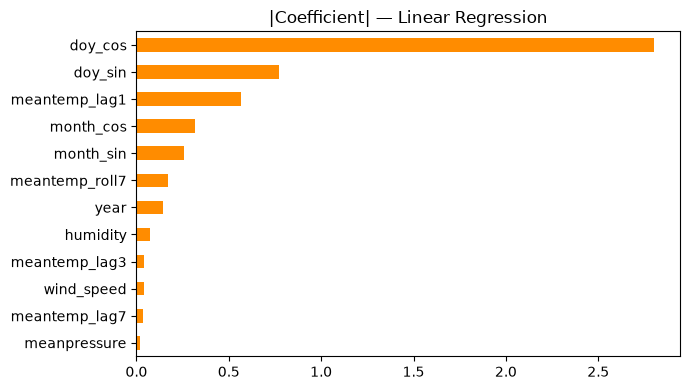

In [9]:
best_model = models[best_name]
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    importance_label = "Feature Importance"
else:
    importances = pd.Series(best_model.coef_, index=FEATURES).abs().sort_values()
    importance_label = "|Coefficient|"

plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="darkorange")
plt.title(f"{importance_label} — {best_name}")
plt.tight_layout()
plt.show()

## 6. Findings

- Adding lagged temperature (1/3/7 days back) and a 7-day rolling mean substantially improves accuracy over calendar/seasonality features alone: MAE drops from ~2.1°C to ~1.3°C and R² rises from ~0.84 to ~0.94.
- **Linear Regression** and **Random Forest** are essentially tied on this feature set, with Gradient Boosting slightly behind — most of the remaining signal is short-term persistence (recent temperature), which even a linear model captures well via the lag features.
- Next steps to push accuracy further: a dedicated time-series model (SARIMA, Prophet) or an explicit multi-day-ahead evaluation — this setup effectively nowcasts using the previous few days' actual temperatures, which is realistic for short-horizon forecasting but should be kept in mind when interpreting the results.
